<a href="https://colab.research.google.com/github/appling2024/MSP/blob/Liza_L/SemAn/TM_SKL_(for_Rushist).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- подходы ТМ
- сущности
- nmf, LSA
- LDA

In [ ]:
import codecs
import os

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
PATH = 'Rushist'
NUM_TOPICS = 10
N_FIRST = 20 # сколько первых слов на тему выводить
MIN_DF = 5
MAX_DF = 0.90
STW_PATH = 'swl.txt'

In [ ]:
with codecs.open(STW_PATH, encoding = 'utf-8') as f:
    stw_list = f.read().split()[1:]

In [ ]:
!pip install nltk

In [ ]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 76.6 MB/s eta 0:00:00


In [ ]:
import nltk
import pymorphy3
from pymorphy3 import MorphAnalyzer

In [ ]:
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
morph = MorphAnalyzer()
def lemmatize(text):
    words = nltk.word_tokenize(text)
    lemmatized_words = [morph.normal_forms(word)[0] for word in words]
    lemmatized = ' '.join(lemmatized_words)
    return lemmatized

In [ ]:
file_names = os.listdir(PATH)
data = []
for name in file_names:
    if name.endswith(".txt"):
        with codecs.open(PATH + "/" + name, encoding = 'utf-8') as f:
            text = f.read()
            lemmatized_text = lemmatize(text)
            data.append(lemmatized_text)
            # each document should contain lemmatized words separated by spaces

In [ ]:
count_vectorizer = CountVectorizer(min_df=MIN_DF, max_df=MAX_DF, stop_words = stw_list)
data_count_vectorized = count_vectorizer.fit_transform(data)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ак', 'бляха', 'богу', 'бу', 'буль', 'вашему', 'вообще', 'всякому', 'го', 'другому', 'ей', 'елки', 'иному', 'кей', 'кис', 'кэй', 'ля', 'мое', 'моему', 'муха', 'нашему', 'нить', 'палки', 'паф', 'пиф', 'пли', 'своему', 'твоему', 'тик', 'тра', 'тс', 'ту', 'чегой', 'черт', 'чик', 'чтой', 'яй'] not in stop_words.
  warnings.warn(


In [ ]:
lda_model = LatentDirichletAllocation(n_components=NUM_TOPICS, max_iter=20, learning_method='batch', batch_size=512, random_state = 2)
lda_model.fit_transform(data_count_vectorized);

In [ ]:
# print function
all_topics = []
def print_topics(model, vectorizer, top_n=N_FIRST):
    for idx, topic in enumerate(model.components_):
        print("Topic %d:" % (idx))
        all_topics.append([(vectorizer.get_feature_names_out()[i], topic[i])
                        for i in topic.argsort()[:-top_n - 1:-1]])
        print([(vectorizer.get_feature_names_out()[i], topic[i])
                        for i in topic.argsort()[:-top_n - 1:-1]])

In [ ]:
print_topics(lda_model, count_vectorizer)

Topic 0:
[('царь', np.float64(814.2653837203324)), ('московский', np.float64(477.12021649847765)), ('государь', np.float64(322.12383235675173)), ('москва', np.float64(241.0680260991779)), ('власть', np.float64(231.03663385610886)), ('боярин', np.float64(220.6203154444873)), ('смута', np.float64(158.7179883727614)), ('класс', np.float64(156.234450247935)), ('боярский', np.float64(150.0143088541082)), ('собор', np.float64(149.0504369785278)), ('династия', np.float64(140.76869274771735)), ('народ', np.float64(140.675057795269)), ('земский', np.float64(134.62137575487714)), ('иван', np.float64(123.20710710320736)), ('михаил', np.float64(115.95903775760573)), ('боярство', np.float64(106.58921654011804)), ('престол', np.float64(96.90980611297378)), ('народный', np.float64(92.26193003215872)), ('алексей', np.float64(86.70127587239219)), ('польский', np.float64(84.26961807931268))]
Topic 1:
[('польша', np.float64(174.0098537944362)), ('война', np.float64(130.90289174853237)), ('россия', np.flo

In [ ]:
for i,topic in enumerate(all_topics):
    print("-------------------------------")
    print("Тема ",i)
    for pair in topic:
        print(pair[0])

-------------------------------
Тема  0
царь
московский
государь
москва
власть
боярин
смута
класс
боярский
собор
династия
народ
земский
иван
михаил
боярство
престол
народный
алексей
польский
-------------------------------
Тема  1
польша
война
россия
политика
екатерина
польский
внешний
турция
западный
союз
турецкий
православный
казак
король
право
граница
правительство
задача
договор
море
-------------------------------
Тема  2
церковный
церковь
статья
юридический
закон
суд
гривна
право
греческий
обычай
устав
источник
никон
русь
памятник
патриарх
древний
книга
нравственный
религиозный
-------------------------------
Тема  3
двор
тяглый
деньга
налог
крестьянин
рубль
подать
сбор
десятина
доход
казна
московский
губерния
земский
платить
финансовый
прямой
посадский
казённый
правительство
-------------------------------
Тема  4
управление
собор
земский
местный
учреждение
выборный
приказ
класс
московский
служилый
дума
правительственный
царь
государь
суд
воевода
правительство
центральный
боярск

In [ ]:
!pip install pyLDAvis

In [ ]:
# визуализация
import pyLDAvis.lda_model

#import sklearn.pyLDAvis

pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, data_count_vectorized, count_vectorizer, mds='tsne')
panel

PreparedData(topic_coordinates=                x           y  topics  cluster       Freq
topic                                                    
5       49.736973  -29.777821       1        1  25.472284
6      105.009293   35.399845       2        1  14.540870
7      -96.590538    0.410417       3        1  14.084745
8      -23.833691  -22.693306       4        1   9.764648
0       45.276306  107.803490       5        1   9.668186
4      119.497292  -57.580269       6        1   7.248580
2      -55.447781  -92.101448       7        1   6.924602
3       19.096165   37.457672       8        1   4.965846
9       31.701353 -106.317917       9        1   3.885434
1      -49.718178   75.152275      10        1   3.444805, topic_info=              Term         Freq        Total Category  logprob  loglift
2138    крестьянин  1220.000000  1220.000000  Default  30.0000  30.0000
6339          царь  1107.000000  1107.000000  Default  29.0000  29.0000
4678          пётр  1291.000000  1291.000000  Default  28.0000  28.0000
2436    московский  1368.000000  1368.000000  Default  27.0000  27.0000
2417     монастырь   445.000000   445.000000  Default  26.0000  26.0000
...            ...          ...          ...      ...      ...      ...
4144         право    42.934362  1041.912766  Topic10  -5.2931   0.1792
729      восточный    33.994314   285.714423  Topic10  -5.5266   1.2395
359         борьба    33.327519   295.981364  Topic10  -5.5464   1.1844
6337  царствование    33.240017   334.171004  Topic10  -5.5490   1.0604
2367           мир    29.632036   274.901535  Topic10  -5.6639   1.1407

[702 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
17        1  0.046921         1598
17        5  0.187684         1598
17        6  0.750737         1598
20        5  0.984507         1613
24        6  0.742318         1642
...     ...       ...          ...
6529      4  0.471971      ярослав
6529      6  0.006378      ярослав
6529      7  0.344411      ярослав
6531      4  0.942093  ярославович
6531      9  0.043818  ярославович

[2457 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 7, 8, 9, 1, 5, 3, 4, 10, 2])

In [ ]:
lda_model.perplexity(data_count_vectorized)

2615.9722275772265

In [ ]:
import gensim
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel

In [ ]:
data_texts = [[text for text in doc.split()] for doc in data]

clean_data = []
for text in data_texts:
    clean_text = []
    for token in text:
        if token not in stw_list:
            if not token.isdigit():
              clean_text.append(token)
    clean_data.append(clean_text)

In [ ]:
vocabulary = corpora.Dictionary(clean_data)
corpus = [vocabulary.doc2bow(line) for line in clean_data]

gensim_model = LdaModel(corpus, NUM_TOPICS, vocabulary)
gensim_model.print_topics()

[(0,
  '0.011*"»" + 0.010*"«" + 0.009*"–" + 0.009*"а" + 0.007*"г." + 0.007*"дело" + 0.006*"русский" + 0.006*"человек" + 0.005*"пётр" + 0.004*"новый"'),
 (1,
  '0.010*"»" + 0.008*"–" + 0.007*"а" + 0.007*"князь" + 0.006*"русский" + 0.006*"человек" + 0.006*"«" + 0.005*"дело" + 0.005*"г." + 0.005*"московский"'),
 (2,
  '0.011*"«" + 0.008*"а" + 0.007*"»" + 0.007*"–" + 0.006*"человек" + 0.006*"г." + 0.005*"князь" + 0.005*"крестьянин" + 0.005*"дело" + 0.004*"московский"'),
 (3,
  '0.010*"»" + 0.008*"«" + 0.007*"–" + 0.006*"князь" + 0.006*"человек" + 0.005*"а" + 0.005*"русский" + 0.005*"крестьянин" + 0.005*"дело" + 0.004*"г."'),
 (4,
  '0.009*"«" + 0.009*"а" + 0.008*"»" + 0.006*"–" + 0.006*"русский" + 0.005*"человек" + 0.005*"г." + 0.005*"князь" + 0.005*"пётр" + 0.005*"в."'),
 (5,
  '0.012*"–" + 0.009*"«" + 0.006*"а" + 0.006*"человек" + 0.006*"князь" + 0.006*"русский" + 0.006*"»" + 0.005*"всё" + 0.005*"московский" + 0.005*"дело"'),
 (6,
  '0.008*"«" + 0.008*"а" + 0.008*"»" + 0.007*"–" + 0.007*

In [ ]:
coherence_model_lda = CoherenceModel(model=gensim_model, corpus=corpus, coherence='u_mass')
coherence_lda = coherence_model_lda.get_coherence()
print('U-Mass: ', coherence_lda)

U-Mass:  -0.1012263376488397


In [ ]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model=gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

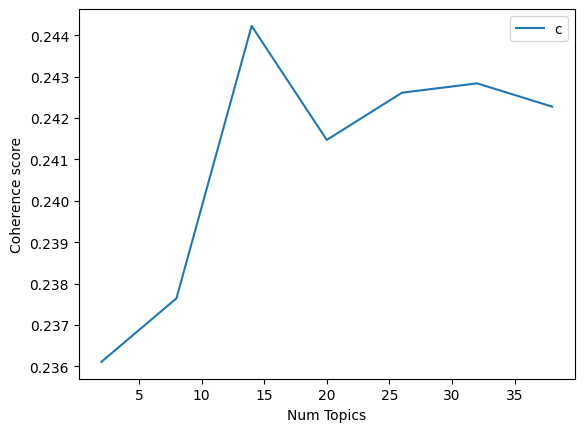

In [ ]:
model_list, coherence_values = compute_coherence_values(dictionary=vocabulary, corpus=corpus, texts=clean_data, start=2, limit=40, step=6)
# Show graph
import matplotlib.pyplot as plt
limit=40; start=2; step=6;
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()